# Homework 7

# Part A

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, load_iris
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    adjusted_rand_score,
    silhouette_score,
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [12]:
# Generate a curved two-cluster dataset
X_moons, true_labels = make_moons(
    n_samples=400,
    noise=0.07,
    random_state=42
)

# Standardize the features
moon_scaler = StandardScaler()
X_moons_scaled = moon_scaler.fit_transform(X_moons)

# Run K-means with two clusters
kmeans_moons = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_moons.fit_predict(X_moons_scaled)

# Run DBSCAN
dbscan_moons = DBSCAN(
    eps=0.25,
    min_samples=5
)

dbscan_labels = dbscan_moons.fit_predict(X_moons_scaled)

# Run K-means with two clusters
kmeans_moons = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_moons.fit_predict(X_moons_scaled)

# Run DBSCAN
dbscan_moons = DBSCAN(
    eps=0.25,
    min_samples=5
)

dbscan_labels = dbscan_moons.fit_predict(X_moons_scaled)

kmeans_ari = adjusted_rand_score(
    true_labels,
    kmeans_labels
)

dbscan_ari = adjusted_rand_score(
    true_labels,
    dbscan_labels
)

print(
    "K-means adjusted Rand index:",
    round(kmeans_ari, 3)
)

print(
    "DBSCAN adjusted Rand index:",
    round(dbscan_ari, 3)
)

K-means adjusted Rand index: 0.475
DBSCAN adjusted Rand index: 0.995


C:\Users\gorg\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\gorg\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


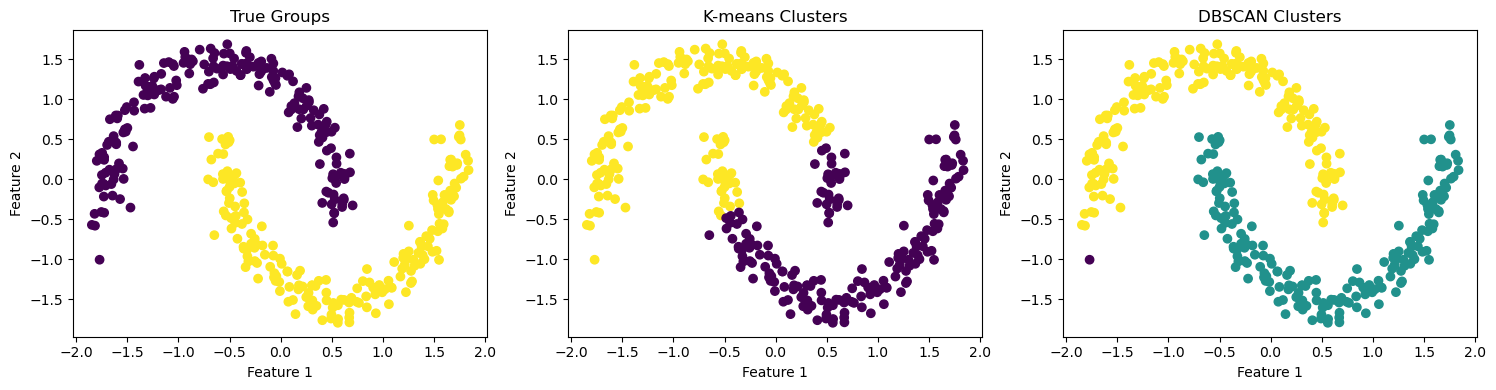

In [13]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

# True groups
axes[0].scatter(
    X_moons_scaled[:, 0],
    X_moons_scaled[:, 1],
    c=true_labels
)

axes[0].set_title("True Groups")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

# K-means clusters
axes[1].scatter(
    X_moons_scaled[:, 0],
    X_moons_scaled[:, 1],
    c=kmeans_labels
)

axes[1].set_title("K-means Clusters")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")

# DBSCAN clusters
axes[2].scatter(
    X_moons_scaled[:, 0],
    X_moons_scaled[:, 1],
    c=dbscan_labels
)

axes[2].set_title("DBSCAN Clusters")
axes[2].set_xlabel("Feature 1")
axes[2].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

In [14]:
rng = np.random.default_rng(42)
n = 100

# Group 1: younger customers with lower income
age_group1 = rng.normal(25, 3, n)
income_group1 = rng.normal(50000, 7000, n)

# Group 2: older customers with similar income
age_group2 = rng.normal(58, 3, n)
income_group2 = rng.normal(52000, 7000, n)

# Group 3: middle-aged customers with higher income
age_group3 = rng.normal(42, 4, n)
income_group3 = rng.normal(125000, 10000, n)

customers = pd.DataFrame({
    "age": np.concatenate([
        age_group1,
        age_group2,
        age_group3
    ]),
    "income": np.concatenate([
        income_group1,
        income_group2,
        income_group3
    ])
})

customers.head()

,age,income
0,25.914151,47352.862122
1,21.880048,59094.598085
2,27.251354,47506.152203
3,27.821694,55162.608979
4,19.146894,43464.676240


In [16]:
X_customers = customers[
    ["age", "income"]
].values

customer_scaler = StandardScaler()

X_customers_scaled = customer_scaler.fit_transform(
    X_customers
)
k_values = range(2, 7)
silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = model.fit_predict(
        X_customers_scaled
    )

    score = silhouette_score(
        X_customers_scaled,
        cluster_labels
    )

    silhouette_scores.append(score)

    print(
        f"k = {k}, "
        f"silhouette score = {score:.3f}"
    )

C:\Users\gorg\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\gorg\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\gorg\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\gorg\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

k = 2, silhouette score = 0.567
k = 3, silhouette score = 0.822
k = 4, silhouette score = 0.663
k = 5, silhouette score = 0.673
k = 6, silhouette score = 0.509


C:\Users\gorg\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [17]:
best_index = np.argmax(silhouette_scores)

best_k = list(k_values)[best_index]
best_score = silhouette_scores[best_index]

print("\nBest number of clusters:", best_k)

print(
    "Highest silhouette score:",
    round(best_score, 3)
)


Best number of clusters: 3
Highest silhouette score: 0.822


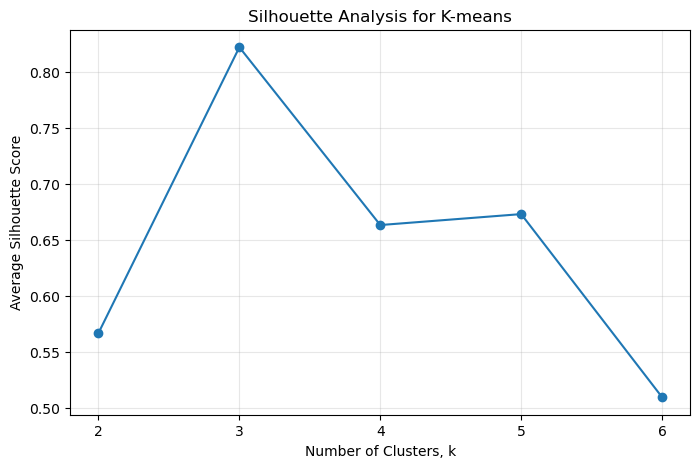

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters, k")
plt.ylabel("Average Silhouette Score")
plt.title("Silhouette Analysis for K-means")

plt.xticks(list(k_values))
plt.grid(alpha=0.3)

plt.show()

In [21]:
iris = load_iris()

# Predictor variables
X_iris = iris.data

# Known class labels
y_iris = iris.target

print("Predictor names:")
print(iris.feature_names)

print("\nClass names:")
print(iris.target_names)

X_train, X_test, y_train, y_test = train_test_split(
    X_iris,
    y_iris,
    test_size=0.30,
    random_state=42,
    stratify=y_iris
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Predictor names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Class names:
['setosa' 'versicolor' 'virginica']
Training observations: 105
Testing observations: 45


1-NN test accuracy: 0.933

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.83      1.00      0.91        15
   virginica       1.00      0.80      0.89        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



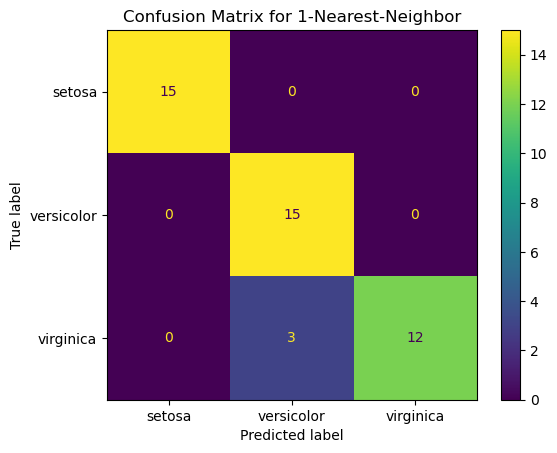

In [23]:
iris_scaler = StandardScaler()

# Fit the scaler using only the training data
X_train_scaled = iris_scaler.fit_transform(
    X_train
)

# Apply the same scaling to the test data
X_test_scaled = iris_scaler.transform(
    X_test
)
knn_model = KNeighborsClassifier(
    n_neighbors=1
)

knn_model.fit(
    X_train_scaled,
    y_train
)

y_pred = knn_model.predict(
    X_test_scaled
)

knn_accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "1-NN test accuracy:",
    round(knn_accuracy, 3)
)

print("\nClassification report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=iris.target_names
)

plt.title(
    "Confusion Matrix for 1-Nearest-Neighbor"
)

plt.show()

# Part C

C:\Users\gorg\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\gorg\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Silhouette score before scaling: 0.768
Silhouette score after scaling: 0.822

Cluster centers before scaling:
   Average Age  Average Income
0        41.58       116232.14
1        41.33        51321.51
2        42.09       132943.30

Cluster centers after scaling:
   Average Age  Average Income
0        57.81        52717.43
1        41.82       124086.39
2        24.85        49925.58


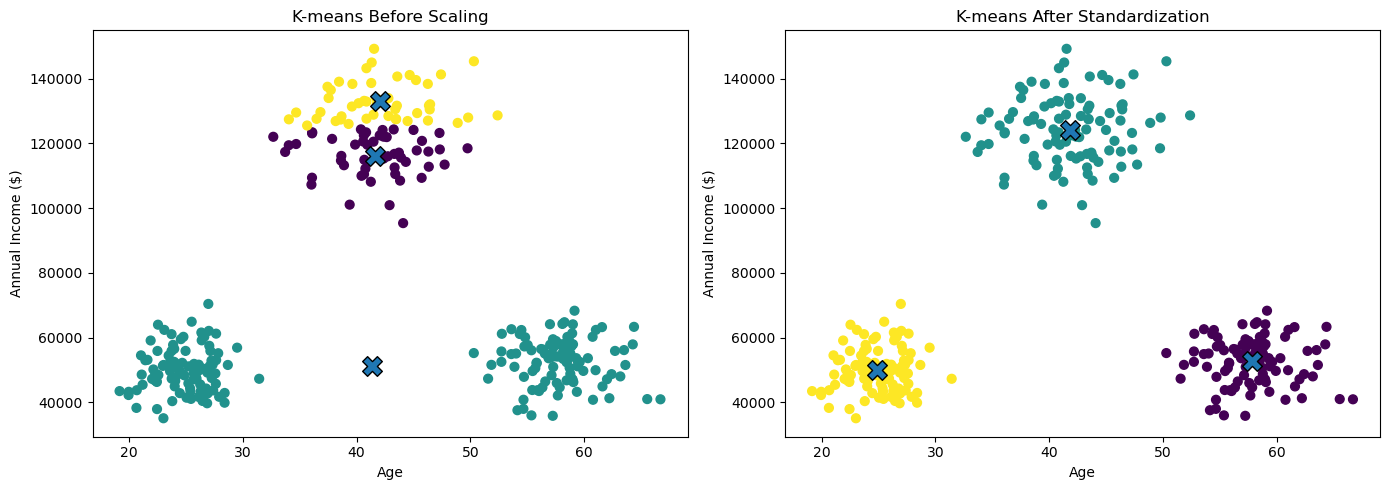

In [24]:
# ---------------------------------------------------------
# 1. Create customer data with age and income
# ---------------------------------------------------------

rng = np.random.default_rng(42)
n = 100

# Group 1: younger customers with lower income
age_group1 = rng.normal(25, 3, n)
income_group1 = rng.normal(50000, 7000, n)

# Group 2: older customers with similar lower income
age_group2 = rng.normal(58, 3, n)
income_group2 = rng.normal(52000, 7000, n)

# Group 3: middle-aged customers with higher income
age_group3 = rng.normal(42, 4, n)
income_group3 = rng.normal(125000, 10000, n)

df = pd.DataFrame({
    "age": np.concatenate([
        age_group1,
        age_group2,
        age_group3
    ]),
    "income": np.concatenate([
        income_group1,
        income_group2,
        income_group3
    ])
})


# ---------------------------------------------------------
# 2. Incorrect K-means without scaling
# ---------------------------------------------------------

X_unscaled = df[["age", "income"]].values

km_unscaled = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["cluster_unscaled"] = km_unscaled.fit_predict(
    X_unscaled
)


# ---------------------------------------------------------
# 3. Correct K-means after standardization
# ---------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    df[["age", "income"]]
)

km_scaled = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["cluster_scaled"] = km_scaled.fit_predict(
    X_scaled
)


# ---------------------------------------------------------
# 4. Calculate silhouette scores
# ---------------------------------------------------------

unscaled_score = silhouette_score(
    X_unscaled,
    df["cluster_unscaled"]
)

scaled_score = silhouette_score(
    X_scaled,
    df["cluster_scaled"]
)

print(
    "Silhouette score before scaling:",
    round(unscaled_score, 3)
)

print(
    "Silhouette score after scaling:",
    round(scaled_score, 3)
)


# ---------------------------------------------------------
# 5. Display cluster centers in original units
# ---------------------------------------------------------

unscaled_centers = pd.DataFrame(
    km_unscaled.cluster_centers_,
    columns=["Average Age", "Average Income"]
)

scaled_centers = pd.DataFrame(
    scaler.inverse_transform(
        km_scaled.cluster_centers_
    ),
    columns=["Average Age", "Average Income"]
)

print("\nCluster centers before scaling:")
print(unscaled_centers.round(2))

print("\nCluster centers after scaling:")
print(scaled_centers.round(2))


# ---------------------------------------------------------
# 6. Plot clusters before and after scaling
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Before scaling
axes[0].scatter(
    df["age"],
    df["income"],
    c=df["cluster_unscaled"],
    s=40
)

axes[0].scatter(
    km_unscaled.cluster_centers_[:, 0],
    km_unscaled.cluster_centers_[:, 1],
    marker="X",
    s=200,
    edgecolors="black"
)

axes[0].set_title("K-means Before Scaling")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Annual Income ($)")


# After scaling
scaled_centers_original = scaler.inverse_transform(
    km_scaled.cluster_centers_
)

axes[1].scatter(
    df["age"],
    df["income"],
    c=df["cluster_scaled"],
    s=40
)

axes[1].scatter(
    scaled_centers_original[:, 0],
    scaled_centers_original[:, 1],
    marker="X",
    s=200,
    edgecolors="black"
)

axes[1].set_title("K-means After Standardization")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Annual Income ($)")

plt.tight_layout()
plt.show()

# Part B

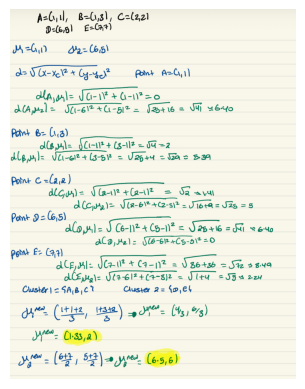

In [38]:
from PIL import Image
import matplotlib.pyplot as plt

img1 = Image.open(r"C:\Users\gorgi\Downloads\seoul4803\IMG_1339.jpeg")

plt.imshow(img1)
plt.axis("off")
plt.show()

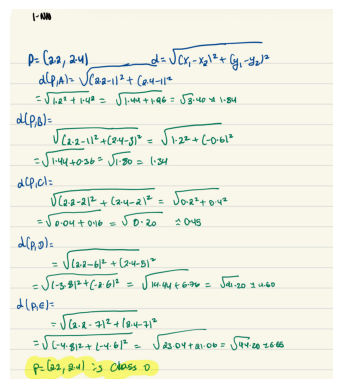

In [37]:
img = Image.open(r"C:\Users\gorgi\Downloads\seoul4803\IMG_1340.jpeg")

plt.imshow(img)
plt.axis("off")
plt.show()

# Part C

The original clustering is not correct because age and income are on very different scales. Age only ranges from about 20 to 70, while income can range from 30,000 to 200,000. Since K-means uses Euclidean distance, income has a much bigger effect on the distance and age is almost ignored. For example, an income difference of $20,000 contributes much more to the calculation than an age difference of 30 years.

I fixed this by using StandardScaler before running K-means. This puts age and income on a similar scale, so both variables can affect the clustering. Before scaling, the clusters were mostly separated by income. After scaling, the clusters were more meaningful because they were based on both age and income, such as younger lower-income customers, older lower-income customers, and middle-aged higher-income customers.

In [31]:
# corrected code
X = df[["age", "income"]].values
# Put age and income on the same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Run K-means on the standardized data
km = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10)
df["cluster"] = km.fit_predict(X_scaled)
df.head()

C:\Users\gorg\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,age,income,cluster_unscaled,cluster_scaled,cluster
0,25.914151,47352.862122,1,2,2
1,21.880048,59094.598085,1,2,2
2,27.251354,47506.152203,1,2,2
3,27.821694,55162.608979,1,2,2
4,19.146894,43464.676240,1,2,2


# Part D

Based on my silhouette analysis, the data supports 3 clusters because k=3 had the highest silhouette score, around 0.822. The silhouette score shows how close each point is to the points in its own cluster compared to the points in another cluster. A higher score means the clusters are more separated and the points fit better within their own group.

Having more clusters does not always mean the model is better. As k gets closer to the total number of observations, the within-cluster distance becomes smaller and can even reach zero if every point is placed in its own cluster. However, those clusters would not really be meaningful. Before scaling, income had more influence because its values were much larger than age, so k=2 looked better. After scaling, age and income had a more equal effect, and k=3 became the best choice.